# Demon Slayer Style Transfer — Demo

Bu notebook gerçek fotoğrafları custom eğitilmiş Demon Slayer LoRA + AnyLoRA + ControlNet kullanarak anime stiline dönüştürür.

**Kullanım:**
1. Runtime(calisma zamani) → Change runtime type (calisma zamani turunu degistir) → **T4 GPU** seçin kaydettikten sonra sag ustten baglanin sol altta t4 yaziyorsa baglanilmistir
2. Hücreleri sırayla çalıştırın
3. ADIM 4'te kendi fotoğrafınızı yükleyin
4. ADIM 5'te dönüştürülmüş sonucu görün
5. ADIMLARI SIRASIYLA TAKIP EDIN

**Not:** İlk çalıştırmada ~2GB model indirilir, o yuzden uzun surebilir.

# ADIM 1: gerekli kutuphaneleri indirir


In [1]:
# Gerekli kütüphaneleri kur
!pip install -q \
    transformers==4.44.2 \
    diffusers==0.30.0 \
    accelerate==1.0.0 \
    peft==0.13.0 \
    safetensors==0.4.5 \
    huggingface_hub==0.25.0 \
    controlnet_aux==0.0.7 \
    opencv-python

print("✅ Paketler kuruldu")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.4/202.4 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.9/330.9 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.5/322.5 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.8/434.8 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 436.4/436.4 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 25.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have hu

# ADIM 2: Modeli ve Egitilen stili indirir

In [2]:
import os
import urllib.request

os.makedirs("/content/models", exist_ok=True)
os.makedirs("/content/lora_weights", exist_ok=True)

# === 1) AnyLoRA Base Model (Hugging Face'den) ===
BASE_MODEL_URL = "https://huggingface.co/Lykon/AnyLoRA/resolve/main/AnyLoRA_noVae_fp16-pruned.ckpt"
BASE_MODEL_PATH = "/content/models/AnyLoRA_noVae_fp16-pruned.ckpt"

if not os.path.exists(BASE_MODEL_PATH):
    print("🔄 AnyLoRA base model indiriliyor (~2GB, 3-5 dakika)...")
    !wget -q --show-progress {BASE_MODEL_URL} -O {BASE_MODEL_PATH}
    print("✅ Base model indirildi")
else:
    print("✅ Base model zaten mevcut")

# === 2) Demon Slayer LoRA (GitHub repo'sundan) ===
LORA_URL = "https://raw.githubusercontent.com/ismailarslan02/photo-style-transfer-/main/lora_weights/demon_slayer_lora_v2.safetensors"
LORA_PATH = "/content/lora_weights/demon_slayer_lora_v2.safetensors"

if not os.path.exists(LORA_PATH):
    print("🔄 Demon Slayer LoRA indiriliyor...")
    urllib.request.urlretrieve(LORA_URL, LORA_PATH)
    file_size = os.path.getsize(LORA_PATH) / (1024*1024)
    print(f"✅ LoRA indirildi ({file_size:.1f} MB)")
else:
    print("✅ LoRA zaten mevcut")

print("\n🎉 Tüm dosyalar hazır!")
print("\n ADIM 3e gecin!")

🔄 AnyLoRA base model indiriliyor (~2GB, 3-5 dakika)...
/content/models/Any 100%[===================>]   1.99G   237MB/s    in 13s     
✅ Base model indirildi
🔄 Demon Slayer LoRA indiriliyor...
✅ LoRA indirildi (36.1 MB)

🎉 Tüm dosyalar hazır!

 ADIM 3e gecin!


# ADIM 3: Pipeline'ı Kur

In [3]:
import torch
from diffusers import (
    StableDiffusionControlNetImg2ImgPipeline,
    ControlNetModel,
    DPMSolverMultistepScheduler,
)

BASE_MODEL_PATH = "/content/models/AnyLoRA_noVae_fp16-pruned.ckpt"
LORA_DIR = "/content/lora_weights"
LORA_FILE = "demon_slayer_lora_v2.safetensors"

print("🔄 ControlNet (canny) indiriliyor...")
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/control_v11p_sd15_canny",
    torch_dtype=torch.float16,
)
print("✅ ControlNet yüklendi")

print("🔄 Stable Diffusion + ControlNet pipeline kuruluyor...")
pipe = StableDiffusionControlNetImg2ImgPipeline.from_single_file(
    BASE_MODEL_PATH,
    controlnet=controlnet,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False,
).to("cuda")

pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe.load_lora_weights(LORA_DIR, weight_name=LORA_FILE)

print("✅ Pipeline hazır, Demon Slayer LoRA yüklendi!")
print("ADIM 4E GECIN!")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

🔄 ControlNet (canny) indiriliyor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:90: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Some weights of the model checkpoint were not used when initializing CLIPTextModel: 
 ['text_model.embeddings.position_ids']
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


✅ Pipeline hazır, Demon Slayer LoRA yüklendi!
ADIM 4E GECIN!


# ADIM 4: Fotoğraf Yükle ve Canny Edge Çıkar

📷 Lütfen dönüştürmek istediğiniz fotoğrafı yükleyin:


Saving forest_test.jpg to forest_test.jpg
📐 Boyut: (512, 512)


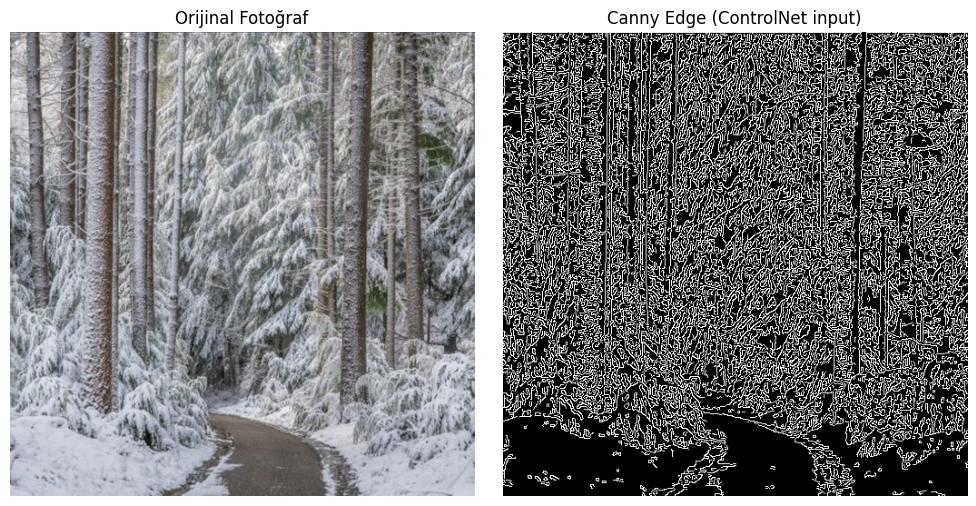

ADIM 5E GECIN!


In [4]:
from google.colab import files
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

print("📷 Lütfen dönüştürmek istediğiniz fotoğrafı yükleyin:")
uploaded = files.upload()
INPUT_PHOTO = list(uploaded.keys())[0]

# 512x512'ye merkezi kırp
def center_crop_resize(img, size=512):
    w, h = img.size
    short = min(w, h)
    left = (w - short) // 2
    top = (h - short) // 2
    img = img.crop((left, top, left + short, top + short))
    return img.resize((size, size), Image.LANCZOS)

input_image = Image.open(INPUT_PHOTO).convert("RGB")
input_image = center_crop_resize(input_image, size=512)
print(f"📐 Boyut: {input_image.size}")

# Canny edge çıkar (ControlNet için yapısal bilgi)
np_image = np.array(input_image)
canny = cv2.Canny(np_image, 100, 200)
canny = np.stack([canny]*3, axis=-1)
canny_image = Image.fromarray(canny)

# Önizleme
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(input_image); axes[0].set_title("Orijinal Fotoğraf"); axes[0].axis('off')
axes[1].imshow(canny_image); axes[1].set_title("Canny Edge (ControlNet input)"); axes[1].axis('off')
plt.tight_layout()
plt.show()
print("ADIM 5E GECIN!")

# ADIM 5: Style transfer


🎨 Dönüştürülüyor — denoise=0.7, controlnet=0.8, lora=0.8


  0%|          | 0/21 [00:00<?, ?it/s]

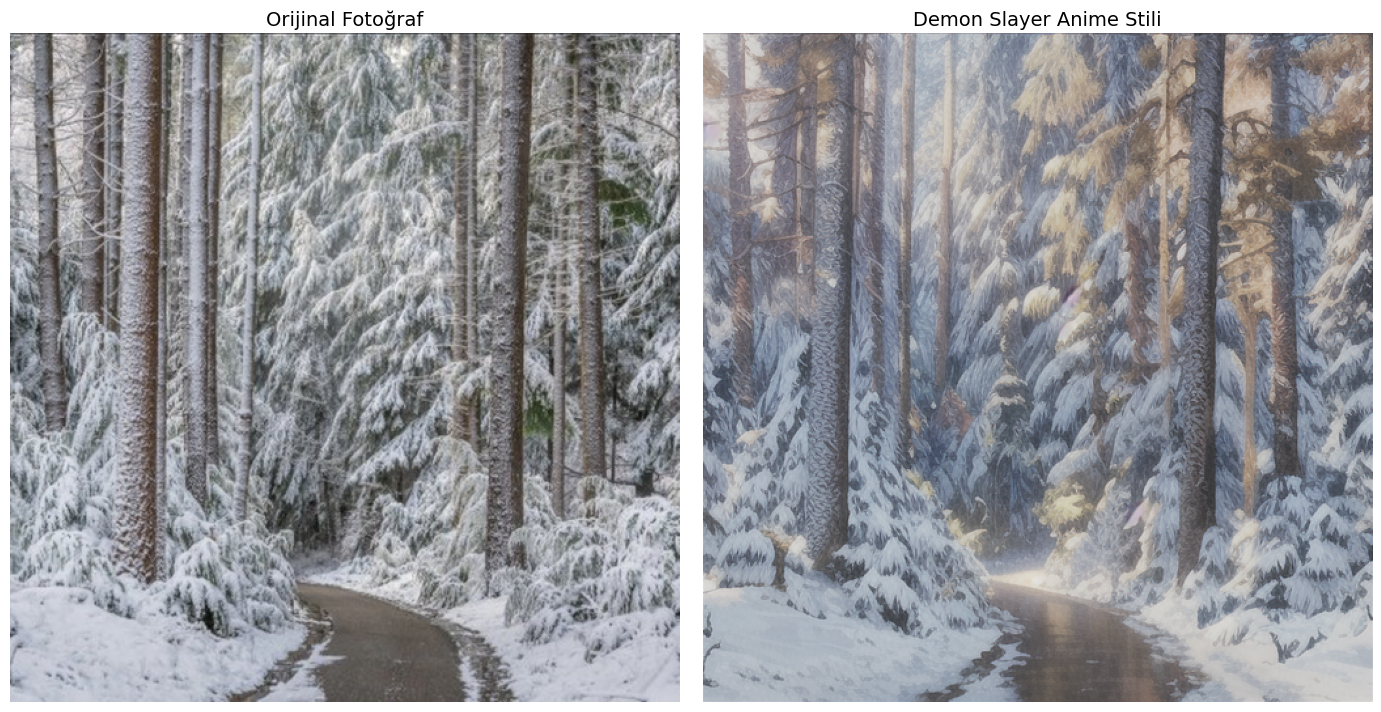


✅ Dönüşüm tamamlandı!


In [8]:
import torch
import matplotlib.pyplot as plt

# === AYARLANABİLİR PARAMETRELER ===
DENOISE = 0.7              # 0.5-0.9 — fotoğrafa sadakat (düşük=fotoğraf gibi, yüksek=anime)
CONTROLNET_SCALE = 0.8     # 0.5-1.0 — yapısal koruma (yüksek=kompozisyon korunur)
LORA_SCALE = 0.8           # 0.5-1.0 — stilinin gücü
SEED = 43                  #  sabit seed degistirilebilir

# Prompt — manzara için
prompt = "dmnslyr_style, forest, outdoors, best quality" #promptlar degistirilmelidir bu sadece manzara icin girilmis prompttur
negative_prompt = "worst quality, low quality"

print(f"🎨 Dönüştürülüyor — denoise={DENOISE}, controlnet={CONTROLNET_SCALE}, lora={LORA_SCALE}")
generator = torch.Generator(device="cuda").manual_seed(SEED)

output = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=input_image,
    control_image=canny_image,
    num_inference_steps=30,
    guidance_scale=7.5,
    strength=DENOISE,
    controlnet_conditioning_scale=CONTROLNET_SCALE,
    cross_attention_kwargs={"scale": LORA_SCALE},
    generator=generator,
).images[0]

# Karşılaştırmalı görüntüleme
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(input_image); axes[0].set_title("Orijinal Fotoğraf", fontsize=14); axes[0].axis('off')
axes[1].imshow(output); axes[1].set_title("Demon Slayer Anime Stili", fontsize=14); axes[1].axis('off')
plt.tight_layout()
plt.show()

print("\n✅ Dönüşüm tamamlandı!")

# ADIM 6: Performans Metrikleri

In [10]:
# === MODEL DEĞERLENDIRME METRİKLERİ ===
import torch
from PIL import Image
import numpy as np

print("📊 Performans metrikleri hesaplanıyor...\n")

# --- 1) CLIP Score (prompt-görsel uyumu) ---
print("🔄 CLIP Score hesaplanıyor...")
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to("cuda")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def calculate_clip_score(image, text):
    inputs = clip_processor(text=[text], images=image, return_tensors="pt", padding=True).to("cuda")
    with torch.no_grad():
        outputs = clip_model(**inputs)
    image_embeds = outputs.image_embeds / outputs.image_embeds.norm(dim=-1, keepdim=True)
    text_embeds = outputs.text_embeds / outputs.text_embeds.norm(dim=-1, keepdim=True)
    similarity = (image_embeds @ text_embeds.T).item()
    return similarity

clip_input = calculate_clip_score(input_image, "anime style")
clip_output = calculate_clip_score(output, "anime style")
clip_demon = calculate_clip_score(output, "demon slayer anime")

print(f"   Orijinal fotoğraf - 'anime style' uyumu: {clip_input:.4f}")
print(f"   Anime çıktı       - 'demon slayer anime' uyumu: {clip_demon:.4f}")
print(f"   📈 Stil dönüşüm artışı: {(clip_output - clip_input):.4f}\n")

# --- 2) SSIM (yapısal benzerlik) ---
print("🔄 SSIM hesaplanıyor...")
from skimage.metrics import structural_similarity as ssim

input_np = np.array(input_image.convert("L"))  # grayscale
output_np = np.array(output.convert("L"))

ssim_value = ssim(input_np, output_np, data_range=255)
print(f"   SSIM (yapısal benzerlik): {ssim_value:.4f}")
print(f"   ℹ️ 1.0 = tam aynı, 0.3-0.6 = iyi stil transferi (yapı korunmuş, stil değişmiş)\n")

# --- 3) Renk Dağılımı Değişimi ---
print("🔄 Renk dağılımı analizi...")
input_rgb = np.array(input_image).mean(axis=(0,1))
output_rgb = np.array(output).mean(axis=(0,1))
print(f"   Orijinal RGB ortalama: R={input_rgb[0]:.1f}, G={input_rgb[1]:.1f}, B={input_rgb[2]:.1f}")
print(f"   Anime RGB ortalama:    R={output_rgb[0]:.1f}, G={output_rgb[1]:.1f}, B={output_rgb[2]:.1f}")

# --- ÖZET ---
print("\n" + "="*50)
print("📋 ÖZET METRİKLER")
print("="*50)
print(f"CLIP Score (anime style):     {clip_output:.4f}")
print(f"CLIP Score (demon slayer):    {clip_demon:.4f}")
print(f"SSIM (yapı koruma):           {ssim_value:.4f}")
print(f"Stil dönüşüm kazancı:         +{(clip_output - clip_input):.4f}")
print("="*50)

📊 Performans metrikleri hesaplanıyor...

🔄 CLIP Score hesaplanıyor...


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


   Orijinal fotoğraf - 'anime style' uyumu: 0.1755
   Anime çıktı       - 'demon slayer anime' uyumu: 0.1940
   📈 Stil dönüşüm artışı: 0.0414

🔄 SSIM hesaplanıyor...
   SSIM (yapısal benzerlik): 0.2621
   ℹ️ 1.0 = tam aynı, 0.3-0.6 = iyi stil transferi (yapı korunmuş, stil değişmiş)

🔄 Renk dağılımı analizi...
   Orijinal RGB ortalama: R=141.3, G=142.5, B=145.7
   Anime RGB ortalama:    R=139.3, G=140.2, B=146.3

📋 ÖZET METRİKLER
CLIP Score (anime style):     0.2169
CLIP Score (demon slayer):    0.1940
SSIM (yapı koruma):           0.2621
Stil dönüşüm kazancı:         +0.0414
